In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../DataSet/house_price.csv")
df.head

<bound method NDFrame.head of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  con

In [3]:
x_train = df[
    [
        "bedrooms",
        "bathrooms",
        "sqft_living",
        "sqft_lot",
        "floors",
        # "waterfront",
        # "view",
        # "condition",
        "sqft_above",
        "sqft_basement",
        # "yr_built",
        # "yr_renovated/",
    ]
].to_numpy()
y_train = df["price"].to_numpy().round(2)

In [4]:
m = x_train.shape[0]  # no of training examples
n = x_train.shape[1]  # no of features
m, n

(4600, 7)

In [ ]:
w = np.zeros(n)
b = 0.0
learning_rate = 1e-12
iterations = 10000

In [6]:
def compute_output(x: np.ndarray, w: np.ndarray, b) -> np.ndarray:
    return np.dot(x, w) + b

In [7]:
def compute_cost(x: np.ndarray, y: np.ndarray, w: np.ndarray, b):
    m = x.shape[0]

    y_hat = compute_output(x, w, b)  # m x 1

    sq_error = (y_hat - y) ** 2

    cost = np.sum(sq_error) / (2 * m)

    return cost

In [8]:
def compute_gradient(x: np.ndarray, y: np.ndarray, w: np.ndarray, b):
    m = x.shape[0]

    y_hat = compute_output(x, w, b)

    error = y_hat - y

    dj_dw = np.dot(x.T, error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

In [9]:
def gradient_descent(x: np.ndarray, y: np.ndarray, w: np.ndarray, b, alpha, iterations):
    m = x.shape[0]
    n = x.shape[1]

    cost_history = []

    for i in range(iterations):

        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost}")

    return w, b, cost_history

In [10]:
w_final, b_final, cost_hist = gradient_descent(
    x_train, y_train, w, b, learning_rate, iterations
)

Iteration 0, Cost: 311163421248.0001
Iteration 100, Cost: 303514781615.9536
Iteration 200, Cost: 297799428201.89856
Iteration 300, Cost: 293513251523.9733
Iteration 400, Cost: 290283614811.5149
Iteration 500, Cost: 287835065633.3325
Iteration 600, Cost: 285963990008.6672
Iteration 700, Cost: 284519876781.7031
Iteration 800, Cost: 283391468288.37476
Iteration 900, Cost: 282496522959.69916
Iteration 1000, Cost: 281774247860.6538
Iteration 1100, Cost: 281179704839.5423
Iteration 1200, Cost: 280679675565.8962
Iteration 1300, Cost: 280249604975.57684
Iteration 1400, Cost: 279871341872.1111
Iteration 1500, Cost: 279531468784.1621
Iteration 1600, Cost: 279220067399.8416
Iteration 1700, Cost: 278929805978.4651
Iteration 1800, Cost: 278655264767.3274
Iteration 1900, Cost: 278392437351.2635
Iteration 2000, Cost: 278138362051.3402
Iteration 2100, Cost: 277890849455.57855
Iteration 2200, Cost: 277648281010.2618
Iteration 2300, Cost: 277409460139.0724
Iteration 2400, Cost: 277173502190.6853
Iterati

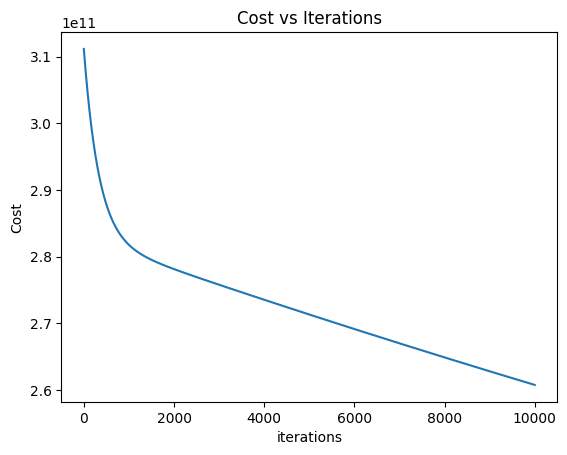

In [15]:
plt.plot(cost_hist)
plt.title("Cost vs Iterations")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

In [16]:
print(f"Final parameters:\n w = {w_final}\nb = {b_final}")

Final parameters:
 w = [1.61179816e-02 1.09205934e-02 1.14492712e+01 5.62857687e+00
 7.22086138e-03 9.54274787e+00 1.90652331e+00]
b = 0.004488542316268136


In [17]:
bedrooms = float(input("Bedrooms: "))
bathrooms = float(input("Bathrooms: "))
sqft_living = float(input("Sqft Living: "))
sqft_lot = float(input("Sqft Lot: "))
floors = float(input("Floors: "))
# waterfront = float(input("Waterfront (0 or 1): "))
# view = float(input("View Rating: "))
# condition = float(input("Condition Rating: "))
sqft_above = float(input("Sqft Above: "))
sqft_basement = float(input("Sqft Basement: "))
# yr_built = float(input("Year Built: "))
# yr_renovated = float(input("Year Renovated (0 if none): "))

# creating feature vector
x_user = np.array(
    [
        bedrooms,
        bathrooms,
        sqft_living,
        sqft_lot,
        floors,
        # waterfront,
        # view,
        # condition,
        sqft_above,
        sqft_basement,
        # yr_built,
        # yr_renovated,
    ]
)

# prediction
predicted_price = compute_output(x_user, w_final, b_final)

print(f"\nPredicted House Price: ${predicted_price:,.2f}")

ValueError: could not convert string to float: ''